In [1]:
from pathlib import Path
import datetime

import torch
import torch.nn.functional as F
from jaxtyping import Int
import matplotlib.pyplot as plt

# custom utils
from muutils.misc import shorten_numerical_to_str
from trnbl import TrainingManager

# from trnbl.loggers.local import LocalLogger
from trnbl.loggers.tensorboard import TensorBoardLogger


from attention_motifs.ae import AttnAEConfig, AttnAE, contrastive_loss
from attention_motifs.dataset.dataset import CollectedAttentionPatternDataloader
from attention_motifs.dataset.util import AttentionPatternMetadata

f:\projects\attention-motifs\.venv\Lib\site-packages\trnbl\loggers\base.py:17: UserWarning: GPUtil not available: No module named 'GPUtil'
  warnings.warn(f"GPUtil not available: {e}")


In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [3]:
BATCH_SIZE: int = 4
N_TRAIN_BATCHES: int = 10
N_VAL_BATCHES: int = 10

In [4]:
TRAIN_LOADER_DATASET = CollectedAttentionPatternDataloader.read(
	"../data/activations/pile_5"
)
VAL_LOADER_DATASET = CollectedAttentionPatternDataloader.read(
	"../data/activations/pile_5_val"
)

TRAIN_LOADER = TRAIN_LOADER_DATASET.dataloader(
	BATCH_SIZE, shuffle=True, max_batches=N_TRAIN_BATCHES
)
VAL_LOADER = VAL_LOADER_DATASET.dataloader(
	BATCH_SIZE, shuffle=True, max_batches=N_VAL_BATCHES
)

print(f"Train loader: {len(TRAIN_LOADER)} batches, {len(TRAIN_LOADER.dataset)} samples")

Train loader: 10 batches, 40 samples


AttentionPatternMetadata(model_name='meta-llama/Llama-3.2-1B', idx_layer=14, idx_head=17, n_ctx=64, prompt_hash=2615552679)


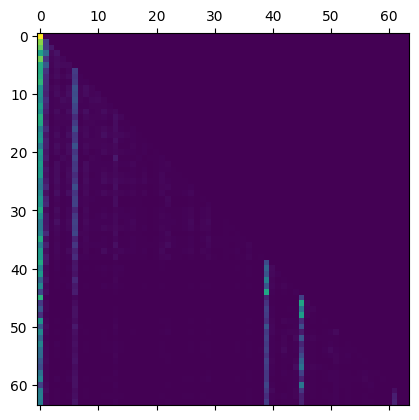

In [20]:
x_mat, x_meta = next(
	iter(VAL_LOADER_DATASET.dataloader(1, shuffle=True, max_batches=1))
)
x_mat.shape
print(x_meta[0])
plt.matshow(x_mat[0])

In [ ]:
MODEL: AttnAE = AttnAE(
	AttnAEConfig(
		latent_dim=128,
	)
)

MODEL_CONFIG: AttnAEConfig = MODEL.config

model_n_params: int = sum(p.numel() for p in MODEL.parameters())
print(
	f"model has {model_n_params} ({shorten_numerical_to_str(model_n_params)}) parameters"
)

# model

In [ ]:
TRAIN_LOADER: torch.utils.data.DataLoader
VAL_LOADER: torch.utils.data.DataLoader | None = None

PROJECT_NAME: str = "contrastive-ae"
CHECKPT_INTERVAL: str = "1/2 run"
EVAL_INTERVAL: str = "1/2 run"
DEVICE: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL = MODEL.to(DEVICE)

In [ ]:
OPTIMIZER: torch.optim.Optimizer
LR_SCHEDULER: torch.optim.lr_scheduler._LRScheduler
OPTIMIZER, LR_SCHEDULER = MODEL_CONFIG.get_optim_and_lrs(MODEL)

In [ ]:
torch.cuda.memory._record_memory_history(
	max_entries=1000000,
)

# setup logger
LOGGER: TensorBoardLogger = TensorBoardLogger(
	log_dir=Path("tb-logs-convAE"),
	name=PROJECT_NAME + datetime.datetime.now().strftime("-%Y-%m-%d-%H-%M-%S"),
	# metric_names=[
	# 	"train/loss",
	# 	"train/recon_loss",
	# 	"train/contrast_loss",
	# 	"val/loss",
	# 	"val/recon_loss",
	# 	"val/contrast_loss",
	# ],
	train_config=dict(
		model_config=MODEL.zanj_model_config.serialize(),
		model_str=str(MODEL),
	),
)

with TrainingManager(
	model=MODEL,
	logger=LOGGER,
	# evals={
	# 	EVAL_INTERVAL: evaluation_step,
	# }.items(),
	checkpoint_interval=CHECKPT_INTERVAL,
) as tr:
	for epoch in tr.epoch_loop(range(MODEL_CONFIG.num_epochs)):
		for patterns, metadata in tr.batch_loop(TRAIN_LOADER):
			this_batch_size: int = len(metadata)

			# move to device
			patterns = patterns.to(DEVICE).to(torch.float32).unsqueeze(1)

			assert patterns.shape[0] == this_batch_size

			# reset gradients
			OPTIMIZER.zero_grad()

			# forward pass
			patterns_recon, embeddings = MODEL(patterns)

			# reconstruction loss
			recon_loss = F.mse_loss(patterns_recon, patterns)

			# compute "classes" for contrastive loss
			# classes is a tensor of the same shape as the batch, where each element is an integer
			classes: Int[torch.Tensor, " batch"] = (
				AttentionPatternMetadata.contrastive_classes(metadata).to(DEVICE)
			)

			# compute contrastive loss
			contrast_loss = contrastive_loss(embeddings, classes)

			# combined loss and backward pass
			total_loss = (
				MODEL_CONFIG.recon_weight * recon_loss
				+ MODEL_CONFIG.contrast_weight * contrast_loss
			)

			# backward pass
			total_loss.backward()
			OPTIMIZER.step()
			LR_SCHEDULER.step(epoch)

			# log metrics
			metrics: dict[str, float] = {
				"train/loss": total_loss.item() / this_batch_size,
				"train/recon_loss": recon_loss.item() / this_batch_size,
				"train/contrast_loss": contrast_loss.item() / this_batch_size,
				"lr": LR_SCHEDULER.get_last_lr()[0],
			}
			tr.batch_update(
				samples=len(metadata),
				**metrics,
			)

			# cleanup
			del (
				patterns,
				patterns_recon,
				embeddings,
				recon_loss,
				contrast_loss,
				total_loss,
			)


torch.cuda.memory._dump_snapshot("CUDA_MEM_SNAPSHOP.pickle")
torch.cuda.memory._record_memory_history(enabled=None)

In [ ]:
MODEL.eval()
print(x_meta[0])
plt.matshow(x_mat[0])
x_recon, x_latent = MODEL(x_mat.to(DEVICE))
plt.matshow(x_recon[0].detach().cpu().numpy())